##FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS

Objective:

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset


Dataset:

The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and the second column represents exchange rates USD to Australian Dollar.


Deliverables:

●	Include visualizations and explanations for the choices and findings at each step.

●	Well-commented Python code that used to conduct the analysis and build the models.


Assessment Criteria:

●	Accuracy and completeness of the data preparation and exploration steps.

●	Justification for model selection and parameter tuning decisions.

●	Clarity and depth of the analysis in the diagnostics and model evaluation stages.
This assignment offers hands-on experience with real-world data, applying sophisticated time series forecasting methods to predict future currency exchange rates.


Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [80]:
# Load dataset
df = pd.read_csv(r"exchange_rate.csv")

# Display first rows
print(df.head())


               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849


In [81]:
#Check Dataset Information
print(df.info())

print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB
None
date       0
Ex_rate    0
dtype: int64


In [82]:
#Parse Date Column
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Set date as index
df.set_index('date', inplace=True )

print(df.head())


            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


Initial exploration

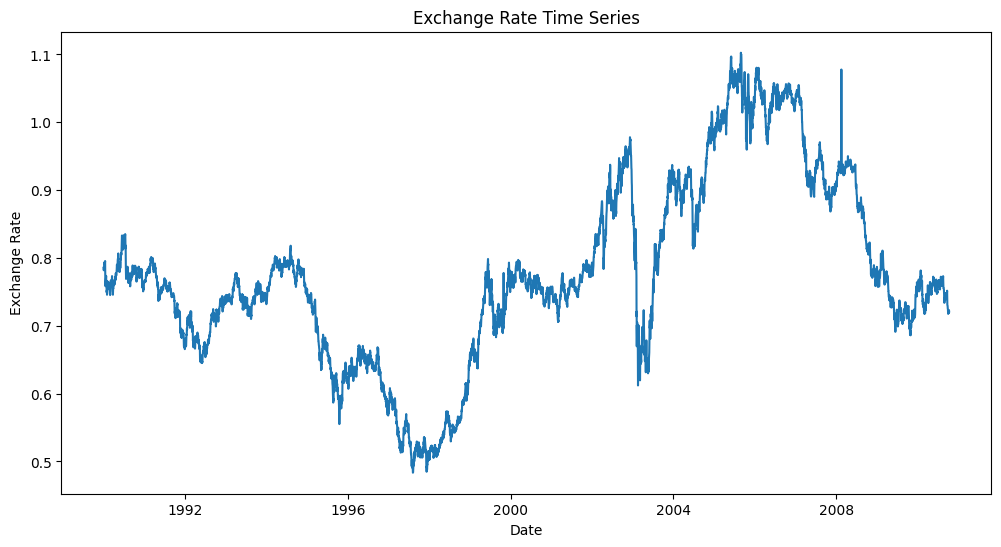

In [83]:
# Plot Time Series
plt.figure(figsize=(12,6))

plt.plot(df.iloc[:,0])

plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()


Data preprocessing

In [84]:
#Handle Missing Values
# Fill missing values using forward fill
df.fillna(method='ffill', inplace=True)

print(df.isnull().sum())

Ex_rate    0
dtype: int64


Check for stationary

If p-value < 0.05 --> Data is stationary

If p-value > 0.05 --> Data is non-stationary

In [85]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


Differencing

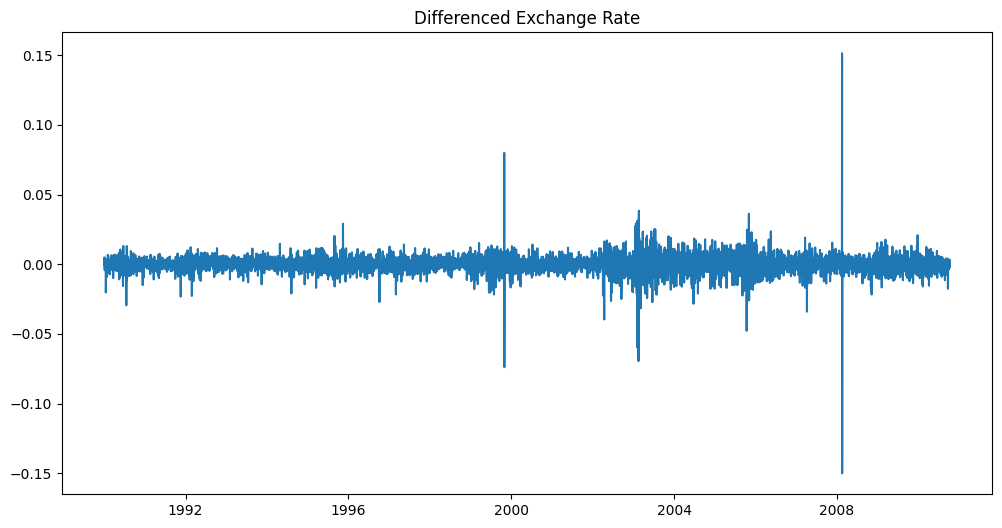

In [86]:
exchange_rate_diff = df.iloc[:,0].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(exchange_rate_diff)
plt.title("Differenced Exchange Rate")
plt.show()

Part 2: Model Building - ARIMA

1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


<Figure size 1200x500 with 0 Axes>

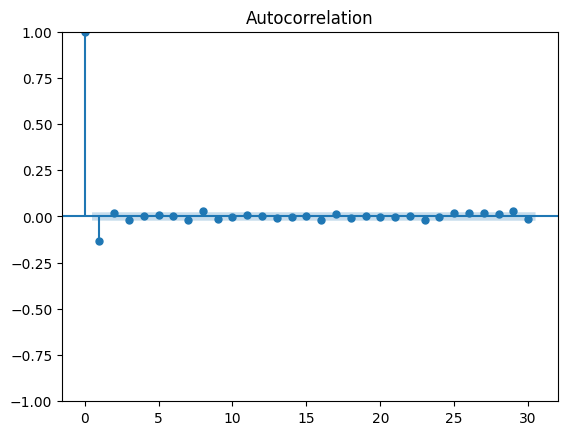

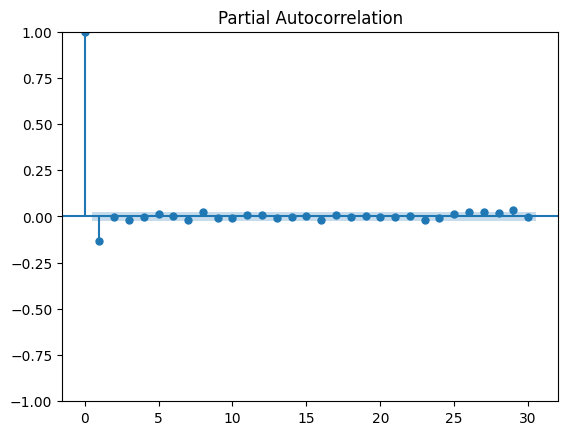

In [87]:
#ACF and PACF Plots
plt.figure(figsize=(12,5))

plot_acf(exchange_rate_diff, lags=30)
plt.show()

plot_pacf(exchange_rate_diff, lags=30)
plt.show()

In [88]:
#train test split
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size, 0]
test = df.iloc[train_size:, 0]

print(train.shape)
print(test.shape)

(6070,)
(1518,)


Fit ARIMA model

In [89]:
# ARIMA(p,d,q)
model_arima = ARIMA(train, order=(1,1,1))

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Tue, 07 Jul 2026   AIC                         -45432.092
Time:                        05:54:56   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

Diagnostics

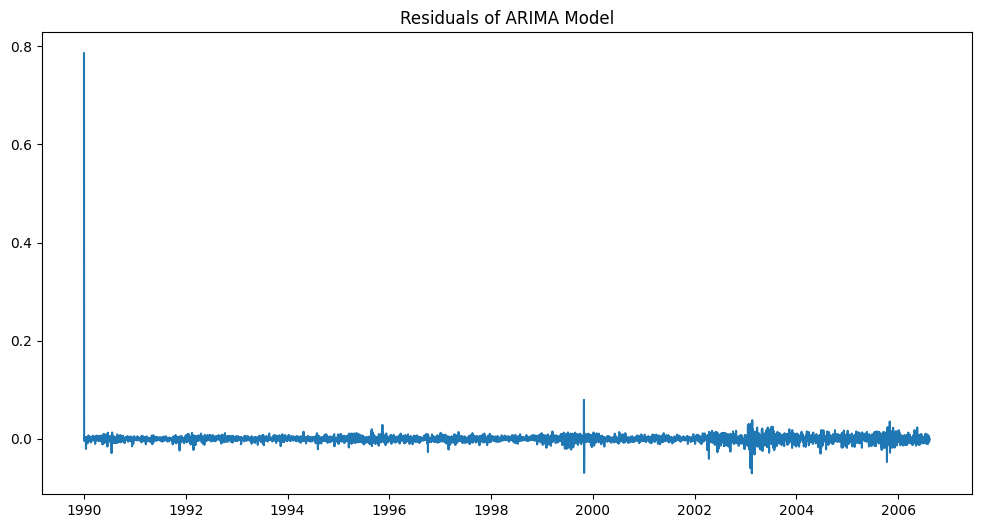

In [90]:
#Residual Analysis
residuals = model_arima_fit.resid

plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.show()


Forecasting using ARIMA

In [91]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

print(forecast_arima)


2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
                ...   
2010-10-06    1.023636
2010-10-07    1.023636
2010-10-08    1.023636
2010-10-09    1.023636
2010-10-10    1.023636
Freq: D, Name: predicted_mean, Length: 1518, dtype: float64


Plot forecast vs Actual

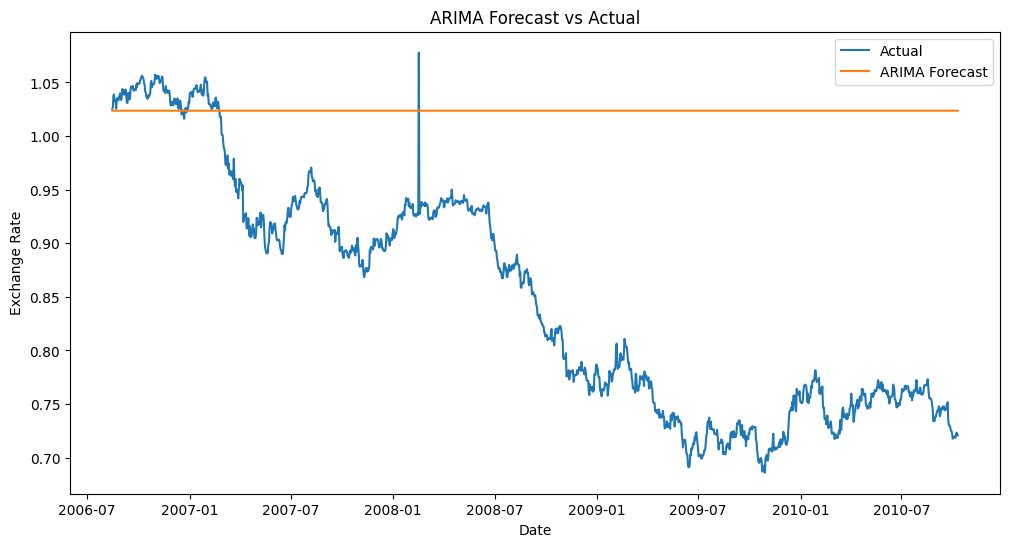

In [92]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()


Exponential smoothing model


In [93]:
model_es = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

In [94]:
# Fit model
model_es_fit = model_es.fit()

In [95]:
# Forecast using Exponential Smoothing
forecast_es = model_es_fit.forecast(len(test))

print(forecast_es)

2006-08-15    1.023675
2006-08-16    1.023459
2006-08-17    1.023588
2006-08-18    1.023816
2006-08-19    1.023866
                ...   
2010-10-06    1.082622
2010-10-07    1.082751
2010-10-08    1.082979
2010-10-09    1.083029
2010-10-10    1.083256
Freq: D, Length: 1518, dtype: float64


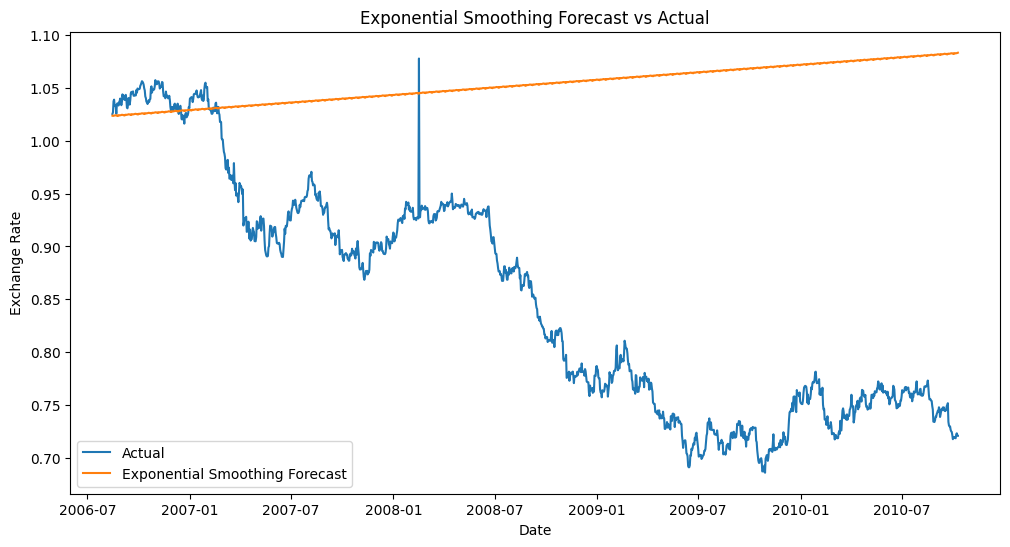

In [96]:
# Plot Forecast vs Actual
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_es, label='Exponential Smoothing Forecast')

plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

In [97]:
from statsmodels.tsa.holtwinters import Holt

# Build Holt Model
model_holt = Holt(train)

# Fit model
fit_holt = model_holt.fit()

# Forecast
forecast_holt = fit_holt.forecast(len(test))

print(forecast_holt.head())

2006-08-15    1.023463
2006-08-16    1.023391
2006-08-17    1.023319
2006-08-18    1.023247
2006-08-19    1.023174
Freq: D, dtype: float64


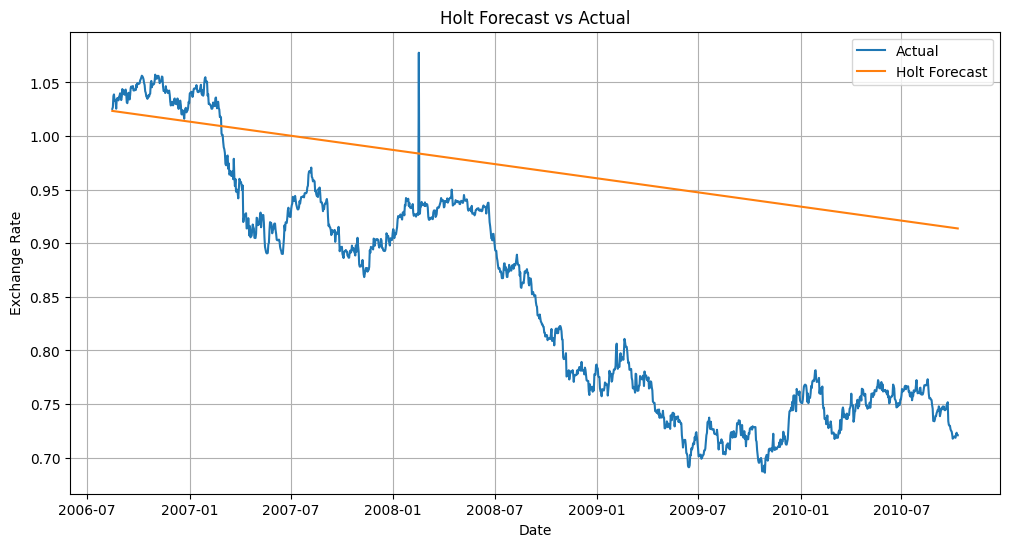

In [98]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast_holt, label='Holt Forecast')

plt.title("Holt Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()

plt.grid(True)

plt.show()

Part 3: Evaluation and Comparison

1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [99]:
#Error Metrics for ARIMA
mae_arima = mean_absolute_error(test, forecast_arima)

rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))

mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE: 0.17770970449121345
ARIMA RMSE: 0.2054366965966928
ARIMA MAPE: 22.797966173811552


In [100]:
#Error Metrics for Exponential Smoothing
mae_es = mean_absolute_error(test, forecast_es)

rmse_es = np.sqrt(mean_squared_error(test, forecast_es))

mape_es = np.mean(np.abs((test - forecast_es) / test)) * 100

print("Exponential Smoothing MAE:", mae_es)
print("Exponential Smoothing RMSE:", rmse_es)
print("Exponential Smoothing MAPE:", mape_es)

Exponential Smoothing MAE: 0.2064936464613419
Exponential Smoothing RMSE: 0.23898512129893612
Exponential Smoothing MAPE: 26.495499980370496


In [101]:
#Model Comparison
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [mae_arima, mae_es],
    'RMSE': [rmse_arima, rmse_es],
    'MAPE': [mape_arima, mape_es]
})

print(comparison)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797966
1  Exponential Smoothing  0.206494  0.238985  26.495500


In [102]:
"""
Conslusion
- ARIMA model captures trends and temporal dependencies effectively.
- Exponential Smoothing performs well for smoother time series data.
- The model with lower MAE, RMSE, and MAPE is considered better.
- ARIMA generally performs better when the data has autocorrelation.
- Exponential Smoothing is simpler and computationally faster.
"""

'\nConslusion\n- ARIMA model captures trends and temporal dependencies effectively.\n- Exponential Smoothing performs well for smoother time series data.\n- The model with lower MAE, RMSE, and MAPE is considered better.\n- ARIMA generally performs better when the data has autocorrelation.\n- Exponential Smoothing is simpler and computationally faster. \n'

In [103]:
""" The best forecasting model is selected based on minimum forecasting error metrics. """

' The best forecasting model is selected based on minimum forecasting error metrics. '